 Imports + dataset CIFAR-10

In [1]:
import torch
import torchvision
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # 3 canaux RGB
])

dataset_train = torchvision.datasets.CIFAR10(
    root='./data', train=True,  transform=transform, download=True
)
dataset_test = torchvision.datasets.CIFAR10(
    root='./data', train=False, transform=transform, download=True
)

classes = dataset_train.classes
print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Visualiser quelques images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.9843137].


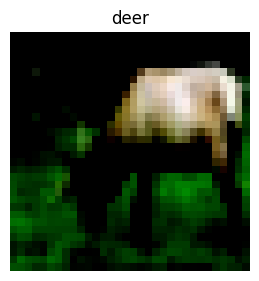

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


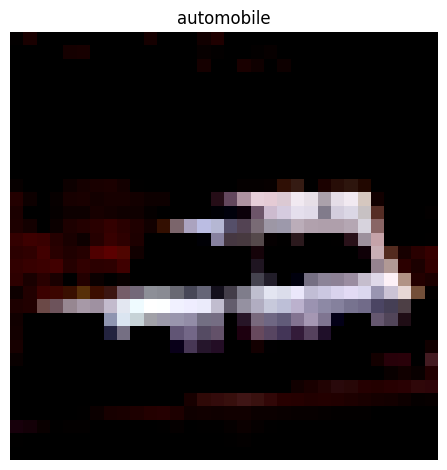

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8901961..1.0].


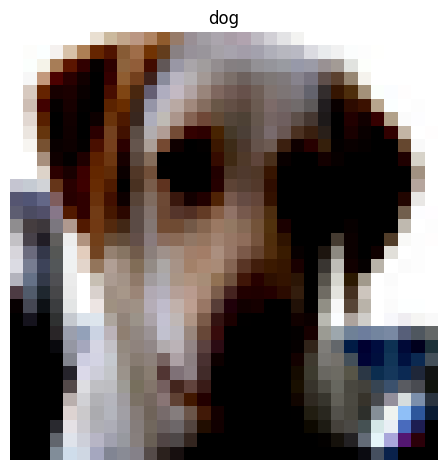

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..1.0].


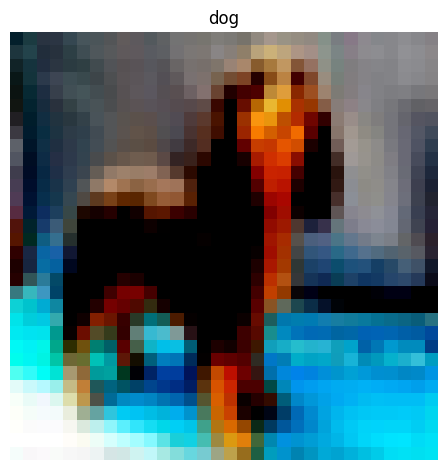

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.7882353].


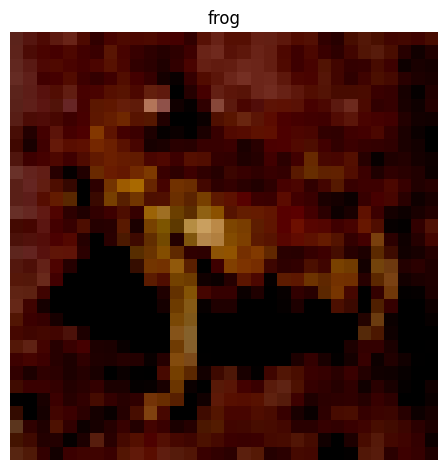

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.827451].


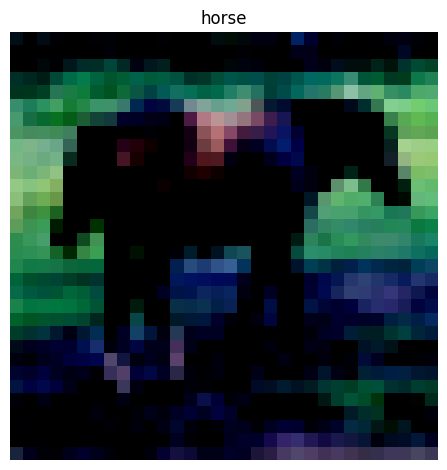

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.84313726..1.0].


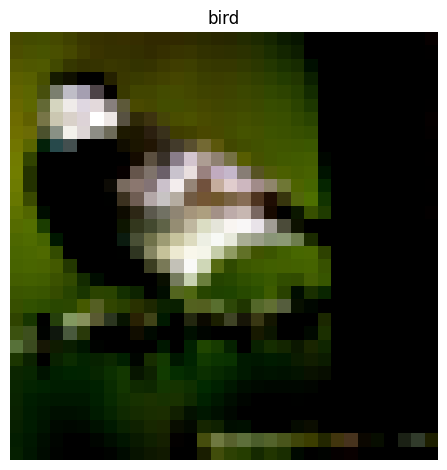

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


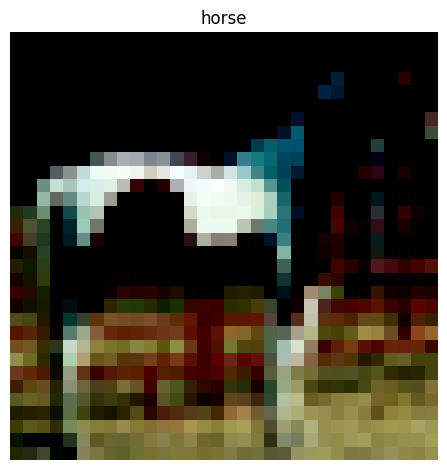

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.70980394].


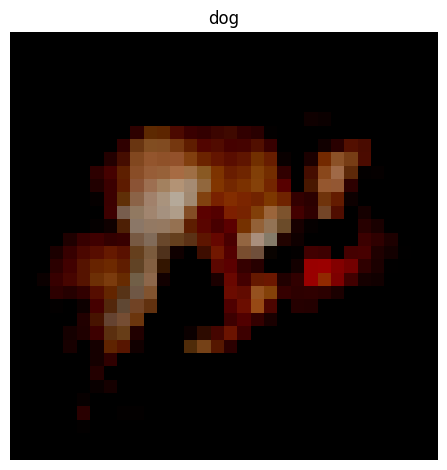

In [3]:
figure = plt.figure(figsize=(8,8))
cols, rows = 3, 3

for i in range(1, cols*rows + 1):
    sample_idx = torch.randint(len(dataset_train), size=(1,)).item()
    img, label = dataset_train[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(classes[label])
    plt.axis("off")
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))

    plt.tight_layout()
    plt.show()

 DataLoader

In [4]:
dataloader_train = DataLoader(dataset_train, batch_size=64, shuffle=True)
dataloader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)

train_features, train_labels = next (iter(dataloader_train))
print(f"Feature batch shape: {train_features.size()}")

Feature batch shape: torch.Size([64, 3, 32, 32])


Définition du modèle

In [9]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*32*3, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.model(x)

mlp = MLP()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(mlp.parameters(), lr=0.01)

def train_loop(dataloader, model, criterion, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (x, y) in enumerate(dataloader):
        pred = model(x)
        loss = criterion(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(x)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test_loop(dataloader, model, criterion):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for x, y in dataloader:
            pred = model(x)
            test_loss += criterion(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error : \n Accuracy : {(100*correct):>0.1f}%, Avg loss : {test_loss:>8f} \n")

epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(dataloader_train, mlp, criterion, optimizer)
    test_loop(dataloader_test, mlp, criterion)

Epoch 1
-------------------------------
loss: 2.300439  [    0/50000]
loss: 2.246061  [ 6400/50000]
loss: 2.178748  [12800/50000]
loss: 2.067717  [19200/50000]
loss: 2.027594  [25600/50000]
loss: 2.008164  [32000/50000]
loss: 2.029989  [38400/50000]
loss: 1.936228  [44800/50000]
Test Error : 
 Accuracy : 33.9%, Avg loss : 1.868340 

Epoch 2
-------------------------------
loss: 1.824702  [    0/50000]
loss: 1.993722  [ 6400/50000]
loss: 1.958907  [12800/50000]
loss: 1.717423  [19200/50000]
loss: 1.839603  [25600/50000]
loss: 1.933578  [32000/50000]
loss: 1.612808  [38400/50000]
loss: 1.765210  [44800/50000]
Test Error : 
 Accuracy : 39.7%, Avg loss : 1.719314 

Epoch 3
-------------------------------
loss: 1.624025  [    0/50000]
loss: 1.783463  [ 6400/50000]
loss: 1.652995  [12800/50000]
loss: 1.620912  [19200/50000]
loss: 2.032128  [25600/50000]
loss: 1.816345  [32000/50000]
loss: 1.649870  [38400/50000]
loss: 1.653854  [44800/50000]
Test Error : 
 Accuracy : 41.8%, Avg loss : 1.6459

Critère, optimiseur et entraînement